# Requirements

In [1]:
!pip install wfdb -q
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 120.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


# Importing the necessary Libraries

In [1]:
import wfdb

import random
import pickle
from enum import Enum

import os
from google.colab import drive

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import matplotlib.pyplot as plt

# Configurations

In [2]:
# ============================================================
# Training - Validation - Testing Records
# ============================================================

TRAIN_RECORDS = ('101', '103', '105', '106', '107', '109',
                 '111', '112', '113', '115', '116', '118',
                 '122', '123', '124', '200', '201','203',
                 '205', '207', '208', '209', '210','212',
                 '213', '214', '215', '219', '220','223',
                 '228', '230', '231', '232', '234') # 35 patient (78%)

VALID_RECORDS = ('119', '108', '100', '221','217') # 5 patient (11%)

TEST_RECORDS = ('222', '202', '117',  '121', '233') # 5 patient (11%)


# ============================================================
# SEGMENTATION CONFIG
# ============================================================

WINDOW_SIZE = 2048
STEP_SIZE = 1024   # 50% overlap

# ============================================================
# NOISE GENERATION CONFIG
# ============================================================

# SNR_LEVELS = [5, 10, 15]
# SNR_LEVELS = [0, 5, 10]
SNR_LEVELS = [0, 1.25, 5]
# Later experiment with: SNR_LEVELS = [-6, 0, 5, 10]

# =========================
# MOUNT GOOGLE DRIVE
# =========================

drive.mount('/content/drive')

# ============================================================
# DATASET PATH CONFIG
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Denoising3"

# ============================================================
# TRAINING CONFIG
# ============================================================
EPOCHS = 20
LR = 1e-4

# ============================================================
# REPRODUCIBILITY CONFIG
# ============================================================
SEED = 17
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ECG Dataset preparation

In [3]:
# patient_list = wfdb.get_record_list('mitdb')
# patient_list = [patient for patient in patient_list if patient not in ['102','104','114']]
# print(f"Total number of records : {len(patient_list)}")

# test_records = random.sample(patient_list,9)
# print(f"Number of test records :{len(test_records)}, test_records = {test_records}")

# train_records = [patient for patient in patient_list if patient not in test_records]
# print(f"Number of train records :{len(train_records)}, train_records = {train_records}")

## Loading signals and preprocessing (normalization, segmentation, ....)

In [3]:
# ============================================================
#
# ============================================================

def normalize_signal(signal):
    # standardization
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    # scaling [-1,1] to match tanh output
    signal = signal / np.max(np.abs(signal))
    return signal

# ============================================================
#
# ============================================================

def load_ecg_record(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    signal = record.p_signal[:, 0] # MLII
    signal = normalize_signal(signal)
    return signal

# ============================================================
#
# ============================================================

def load_noise_signals():
    print("Loading BW noise...")
    bw_record = wfdb.rdrecord('bw', pn_dir='nstdb')
    bw_noise = bw_record.p_signal[:, 0]

    print("Loading MA noise...")
    ma_record = wfdb.rdrecord('ma', pn_dir='nstdb')
    ma_noise = ma_record.p_signal[:, 0]

    bw_noise = normalize_signal(bw_noise)
    ma_noise = normalize_signal(ma_noise)

    return bw_noise, ma_noise

# ============================================================
#
# ============================================================

def segment_signal(signal,record_name,window=WINDOW_SIZE,step=STEP_SIZE):
    segments = []
    metadata = []
    seg_idx = 0

    for start in range(0, len(signal) - window, step):
        end = start + window
        seg = signal[start:end]
        segments.append(seg)
        metadata.append({'record': record_name,'segment_idx': seg_idx,'start': start,'end': end})
        seg_idx += 1
    return np.array(segments), metadata

## Noisy signal generation

In [4]:
# ============================================================
# NOISE TYPE ENUM
# ============================================================

class ECGNoiseType(Enum):
    BW = 1
    MA = 2
    BOTH = 3

In [5]:
# ============================================================
#  Add noise with specified snr in db
# ============================================================
def add_noise_snr(clean, noise, target_snr_db):
    # noise and ecg signal of similar length 650000 samples (360 sample/sec) (record is 30.0925 mins)
    # Signal power
    signal_power = np.mean(clean ** 2)
    # Noise power
    noise_power = np.mean(noise ** 2)
    # Convert SNR from dB
    target_snr_linear = 10 ** (target_snr_db / 10)
    # Required noise power
    required_noise_power = signal_power / target_snr_linear
    # Scale factor
    scale = np.sqrt(required_noise_power / noise_power)
    # Scale noise
    scaled_noise = noise * scale
    # Create noisy ECG
    noisy = clean + scaled_noise
    return noisy

# ============================================================
# CALCULATE ACTUAL SNR
# ============================================================
def calculate_snr(clean,noisy):
    noise = noisy - clean
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

def compute_snr(clean, denoised):
    if isinstance(clean, torch.Tensor):
        clean = clean.detach().cpu().numpy()
    if isinstance(denoised, torch.Tensor):
        denoised = denoised.detach().cpu().numpy()

    noise = clean - denoised
    signal_power = np.sum(clean ** 2)
    noise_power = np.sum(noise ** 2)

    if noise_power == 0:
        return float("inf")  # Perfect reconstruction
    return 10 * np.log10(signal_power / noise_power)

In [6]:
# ============================================================
# GENERATE NOISY ECG BY RANDOM CHOICE OF NOISE TYPE AND SNR
# ============================================================

def generate_noisy_ecg(clean_segment,bw_noise,ma_noise,target_snr_levels=SNR_LEVELS):

    seg_len = len(clean_segment)

    # Random positions
    start_idx = np.random.randint(0,len(bw_noise) - seg_len) # len(bw_noise) = len(ma_noise)

    # Random noise mode
    mode = np.random.choice([
        ECGNoiseType.BW,
        ECGNoiseType.MA
    ])

    if mode == ECGNoiseType.BW:
        bw_seg = bw_noise[start_idx:start_idx + seg_len]
        noise = bw_seg

    else:
        ma_seg = ma_noise[start_idx:start_idx + seg_len]
        noise = ma_seg

    # Random SNR
    target_snr_db = random.choice(target_snr_levels)

    noisy = add_noise_snr(clean_segment,noise,target_snr_db)

    # clipping
    noisy = np.clip(noisy, -1, 1)

    # should be approx to target_snr_db
    actual_snr = calculate_snr(clean_segment,noisy)

    return (noisy,target_snr_db,actual_snr,mode.name)

In [7]:
# ============================================================
# CREATE DATASET
# ============================================================

def create_dataset(record_list,bw_noise,ma_noise):

    clean_data = []
    noisy_data = []
    metadata = []

    for rec in tqdm(record_list):
        print(f"\nProcessing Record: {rec}")
        signal = load_ecg_record(rec)
        segments, seg_metadata = segment_signal(signal,rec)

        for seg, meta in zip(segments,seg_metadata):

            (noisy_seg,target_snr,actual_snr,noise_type) = generate_noisy_ecg(seg,bw_noise,ma_noise)

            clean_data.append(seg)
            noisy_data.append(noisy_seg)

            # Add metadata
            meta['target_snr_db'] = target_snr
            meta['actual_snr_db'] = actual_snr
            meta['noise_type'] = noise_type
            metadata.append(meta)

    clean_data = np.array(clean_data)
    noisy_data = np.array(noisy_data)

    # Add channel dimension
    clean_data = clean_data[:, np.newaxis, :]
    noisy_data = noisy_data[:, np.newaxis, :]

    return noisy_data, clean_data, metadata

## Saving and Loading datasets

In [8]:
# ============================================================
# SAVE METADATA
# ============================================================

def save_metadata(metadata,filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(metadata, f)

# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata(filepath):
    with open(filepath, 'rb') as f:
        metadata = pickle.load(f)
    return metadata

### creating datasets (train, validation, test)

In [10]:
# # =========================
# # LOAD NOISE
# # =========================

# bw_noise, ma_noise = load_noise_signals()

# # =========================
# # CREATE TRAIN DATASET
# # =========================

# print("\nCreating TRAIN dataset...")

# x_train, y_train, train_metadata = create_dataset(TRAIN_RECORDS,bw_noise,ma_noise)

# print("\nTrain Shapes:")
# print("x_train:", x_train.shape)
# print("y_train:", y_train.shape)
# print("train_metadata:", len(train_metadata))

# # =========================
# # CREATE VALIDATION DATASET
# # =========================

# print("\nCreating VALIDATION dataset...")

# x_valid, y_valid, valid_metadata = create_dataset(VALID_RECORDS,bw_noise,ma_noise)

# print("\nValidation Shapes:")
# print("x_valid:", x_valid.shape)
# print("y_valid:", y_valid.shape)
# print("valid_metadata:", len(valid_metadata))

# # =========================
# # CREATE TEST DATASET
# # =========================

# print("\nCreating TEST dataset...")

# x_test, y_test, test_metadata = create_dataset(TEST_RECORDS,bw_noise,ma_noise)

# print("\nTest Shapes:")
# print("x_test:", x_test.shape)
# print("y_test:", y_test.shape)
# print("test_metadata:", len(test_metadata))

Loading BW noise...
Loading MA noise...

Creating TRAIN dataset...


  0%|          | 0/35 [00:00<?, ?it/s]


Processing Record: 101


  3%|▎         | 1/35 [00:16<09:25, 16.63s/it]


Processing Record: 103


...


Processing Record: 121


 80%|████████  | 4/5 [01:39<00:25, 25.37s/it]


Processing Record: 233


100%|██████████| 5/5 [02:01<00:00, 24.28s/it]


Test Shapes:
x_test: (3165, 1, 2048)
y_test: (3165, 1, 2048)
test_metadata: 3165


### saving datasets to google drive for easier reload

In [11]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving datasets to Google Drive...")

# np.save(os.path.join(SAVE_DIR, "x_train.npy"), x_train)
# np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
# save_metadata(train_metadata,os.path.join(SAVE_DIR, "train_metadata.pkl"))

# np.save(os.path.join(SAVE_DIR, "x_valid.npy"), x_valid)
# np.save(os.path.join(SAVE_DIR, "y_valid.npy"), y_valid)
# save_metadata(valid_metadata,os.path.join(SAVE_DIR, "valid_metadata.pkl"))

# np.save(os.path.join(SAVE_DIR, "x_test.npy"), x_test)
# np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)
# save_metadata(test_metadata,os.path.join(SAVE_DIR, "test_metadata.pkl"))

# print("\nDatasets saved successfully!")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Denoising3

Saving datasets to Google Drive...

Datasets saved successfully!


# DataLoader

In [12]:
# =========================
# TRAIN LOADER
# =========================

x_train = np.load(os.path.join(SAVE_DIR, "x_train.npy"))
y_train = np.load(os.path.join(SAVE_DIR, "y_train.npy"))
train_metadata = load_metadata(os.path.join(SAVE_DIR, "train_metadata.pkl"))

print("\nReload successful!")
print(x_train.shape)
print(y_train.shape)
print(len(train_metadata))


x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(x_train, y_train),batch_size=64,shuffle=True)

# =========================
# VALIDATION LOADER
# =========================

x_valid = np.load(os.path.join(SAVE_DIR, "x_valid.npy"))
y_valid = np.load(os.path.join(SAVE_DIR, "y_valid.npy"))
valid_metadata = load_metadata(os.path.join(SAVE_DIR, "valid_metadata.pkl"))

print("\nReload successful!")
print(x_valid.shape)
print(y_valid.shape)
print(len(valid_metadata))


x_valid = torch.tensor(x_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

valid_loader = DataLoader(TensorDataset(x_valid, y_valid),batch_size=64,shuffle=False)


# =========================
# TEST LOADER
# =========================

x_test = np.load(os.path.join(SAVE_DIR, "x_test.npy"))
y_test = np.load(os.path.join(SAVE_DIR, "y_test.npy"))
test_metadata = load_metadata(os.path.join(SAVE_DIR, "test_metadata.pkl"))

print("\nReload successful!")
print(x_test.shape)
print(y_test.shape)
print(len(test_metadata))


x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

test_loader = DataLoader(TensorDataset(x_test, y_test),batch_size=64,shuffle=False)


Reload successful!
(22155, 1, 2048)
(22155, 1, 2048)
22155

Reload successful!
(3165, 1, 2048)
(3165, 1, 2048)
3165

Reload successful!
(3165, 1, 2048)
(3165, 1, 2048)
3165


True


# CAE Models

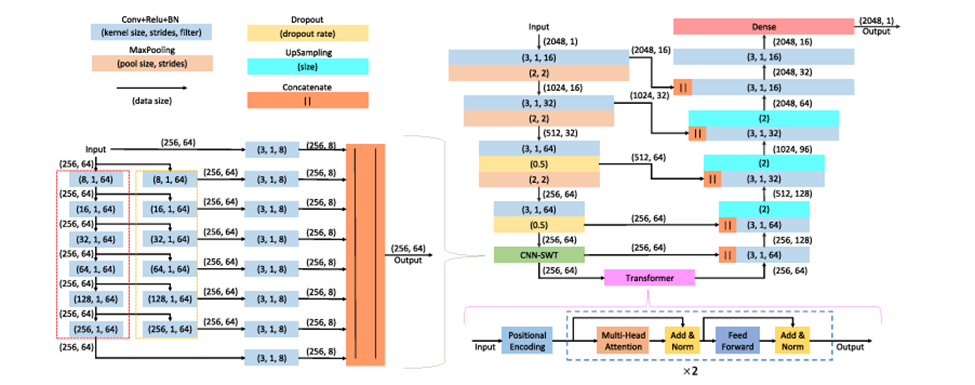

## Model 1.1: CAE (Conv,Relu,BN) (3 layer)

In [13]:
class SimpleCAE(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(SimpleCAE, self).__init__()

        # Helper function for a standard convolutional block
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU() # to avoid overriding it for correct skip connections
            )

        # input laye (2048,1)

        # --- Encoder Path ---
        # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        # Level 3: (512, 32) -> (512, 64) -> (256, 64)
        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)

        # --- Bridge (Bottleneck) ---
        # The center of the U where the lowest resolution features are processed
        # level 4: (256, 64) -> (128, 64)
        self.enc4 = conv_block(64, 64)
        self.pool4 = nn.MaxPool1d(2)

        # --- Decoder Path ---
        # Level 4': Upsample
        # Level 4': (128, 64) -> (256, 64) -> (256, 64)
        # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec4 = conv_block(64, 64)

        # Level 3': Upsample
        # Level 3': (256, 64) -> (512, 64) -> (512, 32)
        # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec3 = conv_block(64, 32)

        # Level 2': Upsample
        # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
        # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
        self.dec2 = conv_block(32, 16)

        # Level 1': Upsample
        # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
        # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

        # self.dec1 = conv_block(16, 1)   # fatal mistake
        self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

        # Final Output Layer (tanh)
        self.final = nn.Tanh()

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # # Bottleneck
        # e4 = self.enc4(p3)
        # p4 = self.pool4(e4)

        # # Decoder
        # u4 = self.up4(p4)
        # d4 = self.dec4(u4)

        u3 = self.up3(p3)
        d3 = self.dec3(u3)

        u2 = self.up2(d3)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        d1 = self.dec1(u1)

        return self.final(d1)

In [14]:
# Test with dummy data [Batch, Channels, Length]
model = SimpleCAE()
input_data = torch.randn(64, 1, 2048)
output = model(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [15]:
summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCAE                                [1, 1, 2048]              33,216
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-4                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-5                  [1, 32, 1024]             64
│    └─ReLU: 2-6                         [1, 32, 1024]             --
├─MaxPool1d: 1-4                         [1, 32, 512]              --
├─Sequential: 1-5                        [1, 64, 512]              --
│    └─Conv1d: 2-7                       [1, 64, 512]              6,208
│    

## Model 1.2: CAE (Conv,Relu,BN) (Deeper, 4 layer)

In [13]:
class ECGAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        # ==================================================
        # Encoder
        # ==================================================

        self.encoder = nn.Sequential(

            # 2048 -> 1024
            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=16,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool1d(2),

            # 1024 -> 512
            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool1d(2),

            # 512 -> 256
            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        # ==================================================
        # Decoder
        # ==================================================

        self.decoder = nn.Sequential(

            # 256 -> 512
            nn.ConvTranspose1d(
                in_channels=64,
                out_channels=32,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # 512 -> 1024
            nn.ConvTranspose1d(
                in_channels=32,
                out_channels=16,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.Conv1d(
                in_channels=16,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # 1024 -> 2048
            nn.ConvTranspose1d(
                in_channels=16,
                out_channels=1,
                kernel_size=2,
                stride=2
            ),

            nn.Tanh()
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [94]:
# Test with dummy data [Batch, Channels, Length]
model = ECGAutoencoder()
input_data = torch.randn(64, 1, 2048)
output = model(input_data)
print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


## Model 2: CAE (Conv, Relu, BN, Dropout)

## Model 3: CAE (Conv, Relu, BN, Dropout, Skip Connections)

## Model 4: CAE (Conv, Relu, BN, Dropout, Skip Connections), smaller bottleneck

## Model 5: CAE (Conv, Relu, BN, Dropout, Skip Connections), larger bottleneck

## Model 6: CAE (Conv, Relu, BN, Dropout, Skip Connections), Dialted Convolution

# Training Loop

In [16]:
# =========================
# Denoising Loss Function
# =========================

class PeakWeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, clean, denoised):

        # ----------------------------------------------------
        # Peak coefficient:
        # Cp = 1 + abs(Xc - median(Xc))
        # ----------------------------------------------------

        median = torch.median(clean, dim=2, keepdim=True)[0]
        Cp = 1 + torch.abs(clean - median)

        # ----------------------------------------------------
        # Improved weighted MSE
        # ----------------------------------------------------

        loss = ((clean - denoised) ** 2) * Cp
        return torch.mean(loss)

In [17]:
def train_model(model, train_loader, valid_loader, criterion =None,epochs=10, lr=LR):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # ==========================================
    # Default Criterion
    # ==========================================
    if criterion is None:
        criterion = PeakWeightedLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train': [], 'valid': []}


    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for noisy, clean in train_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            # ---------------------------------------------
            # Forward
            # ---------------------------------------------

            denoised = model(noisy)
            loss = criterion(denoised,clean)

            # ---------------------------------------------
            # Backprop
            # ---------------------------------------------

            optimizer.zero_grad()

            loss.backward()

            # Gradient clipping
            # torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            optimizer.step()

            # ---------------------------------------------
            # Accumulate
            # ---------------------------------------------

            train_loss += (loss.item() * noisy.size(0))

        # =================================================
        # VALIDATION
        # =================================================

        model.eval()
        valid_loss = 0.0

        with torch.no_grad():
            for noisy, clean in valid_loader:
                noisy = noisy.to(device)
                clean = clean.to(device)
                denoised = model(noisy)
                loss = criterion(denoised,clean)
                valid_loss += (loss.item() * noisy.size(0))

        # =================================================
        # Epoch Metrics
        # =================================================

        epoch_train = train_loss / len(train_loader.dataset)
        epoch_valid = valid_loss / len(valid_loader.dataset)

        history['train'].append(epoch_train)
        history['valid'].append(epoch_valid)

        print(f"Epoch {epoch+1}/{epochs} - Train: {epoch_train:.6f} | Val: {epoch_valid:.6f}")

    return history


In [67]:
models_to_test = {
    "ECGAutoencoder": ECGAutoencoder()
}
criterion = nn.MSELoss()
for name, model in models_to_test.items():
    print(f"Training {name} model...")
    history = train_model(model, train_loader, valid_loader,criterion)

Training ECGAutoencoder model...
Epoch 1/10 - Train: 0.038627 | Val: 0.005575
Epoch 2/10 - Train: 0.003913 | Val: 0.003232
Epoch 3/10 - Train: 0.002536 | Val: 0.002368
Epoch 4/10 - Train: 0.002184 | Val: 0.002316
Epoch 5/10 - Train: 0.002062 | Val: 0.002147
Epoch 6/10 - Train: 0.001995 | Val: 0.002071
Epoch 7/10 - Train: 0.001942 | Val: 0.002058
Epoch 8/10 - Train: 0.001919 | Val: 0.002044
Epoch 9/10 - Train: 0.001887 | Val: 0.001994
Epoch 10/10 - Train: 0.001872 | Val: 0.002006


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelx = SimpleCAE().to(device)
print(f"Training SimpleCAE model...")
criterion = nn.MSELoss()
history = train_model(modelx, train_loader, valid_loader,criterion)

Training SimpleCAE model...
Epoch 1/10 - Train: 0.007012 | Val: 0.005249
Epoch 2/10 - Train: 0.004569 | Val: 0.004869
Epoch 3/10 - Train: 0.004302 | Val: 0.004753
Epoch 4/10 - Train: 0.004167 | Val: 0.004589
Epoch 5/10 - Train: 0.004069 | Val: 0.004614
Epoch 6/10 - Train: 0.004017 | Val: 0.004526
Epoch 7/10 - Train: 0.003968 | Val: 0.004389
Epoch 8/10 - Train: 0.003933 | Val: 0.004334
Epoch 9/10 - Train: 0.003909 | Val: 0.004380
Epoch 10/10 - Train: 0.003879 | Val: 0.004316


In [41]:
print(f"Testing SimpleCAE model...")
results = evaluate_model(modelx,test_loader,criterion)


Testing SimpleCAE model...
Test Loss           : 0.003863
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 6.41 dB
SNR Improvement     : 4.35 dB


## training, validation loss with epochs

In [19]:
def train_valid_loss_plt(history):
  plt.figure(figsize=(12, 6))

  for name, val_list in history.items():
      plt.plot(val_list, label=f'{name} Loss')

  plt.title('Model Comparison: Training VS Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Peak Weighted MSE Loss')
  plt.yscale('log') # Useful if losses vary greatly
  plt.legend()
  plt.grid(True)
  plt.show()


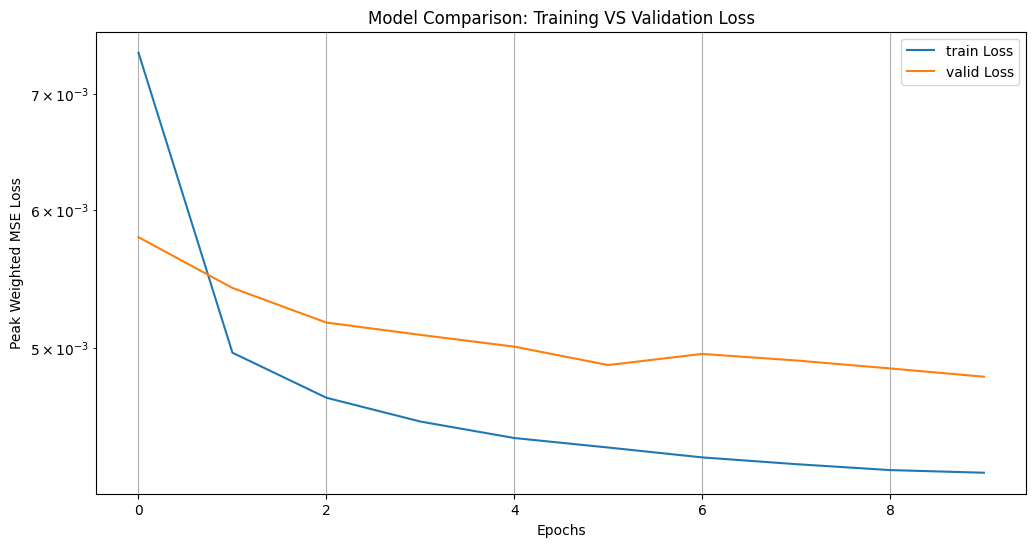

In [20]:
train_valid_loss_plt(history)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCAE().to(device)

# ==========================================
# Default Criterion
# ==========================================

criterion = PeakWeightedLoss()

optimizer = optim.Adam(model.parameters(),LR )
train_loss =[]
for epoch in range(10):
    model.train()
    total_loss = 0

    for noisy, clean in train_loader:
        noisy, clean = noisy.to(device), clean.to(device)

        pred = model(noisy)
        loss = criterion(pred, clean)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer.step()


        total_loss += loss.item()
    train_loss.append(total_loss)
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

Epoch 1: Loss = 2.1656
Epoch 2: Loss = 0.8400
Epoch 3: Loss = 0.7774
Epoch 4: Loss = 0.7437
Epoch 5: Loss = 0.7224
Epoch 6: Loss = 0.7087
Epoch 7: Loss = 0.7011
Epoch 8: Loss = 0.6951
Epoch 9: Loss = 0.6873
Epoch 10: Loss = 0.6791


In [31]:
model.eval()

snr_noisy_list = []
snr_denoised_list = []

with torch.no_grad():
    for noisy, clean in test_loader:
        noisy = noisy.to(device)
        clean = clean.numpy()

        denoised = model(noisy).cpu().numpy()
        noisy_np = noisy.cpu().numpy()

        for i in range(len(clean)):
            snr_noisy = compute_snr(clean[i,0], noisy_np[i,0])
            snr_denoised = compute_snr(clean[i,0], denoised[i,0])

            snr_noisy_list.append(snr_noisy)
            snr_denoised_list.append(snr_denoised)

print("Avg SNR (Noisy):", np.mean(snr_noisy_list))
print("Avg SNR (Denoised):", np.mean(snr_denoised_list))
print("Improvement:", np.mean(snr_denoised_list) - np.mean(snr_noisy_list))

Avg SNR (Noisy): 9.978209
Avg SNR (Denoised): 10.180633
Improvement: 0.20242405


In [ ]:
# Avg SNR (Noisy): 9.978209
# Avg SNR (Denoised): 10.017387
# Improvement: 0.03917885

# Evaluation

In [21]:
def compute_snr(clean, denoised):

    # ==========================================
    # Convert tensors to numpy
    # ==========================================

    if isinstance(clean, torch.Tensor):
        clean = clean.detach().cpu().numpy()

    if isinstance(denoised, torch.Tensor):
        denoised = (denoised.detach().cpu().numpy())

    # ==========================================
    # Noise
    # ==========================================

    noise = clean - denoised

    # ==========================================
    # Power
    # ==========================================

    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)

    # ==========================================
    # Prevent division by zero
    # ==========================================

    if noise_power < 1e-12:
        return float('inf')

    # ==========================================
    # SNR
    # ==========================================

    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [22]:
def evaluate_model(model,test_loader, criterion=None):

    # ==========================================
    # Device
    # ==========================================

    device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
    model = model.to(device)

    # ==========================================
    # Default Criterion
    # ==========================================

    if criterion is None:
        criterion = PeakWeightedLoss()

    model.eval()

    # ==========================================
    # Metrics
    # ==========================================

    total_loss = 0.0
    snr_noisy_list = []
    snr_denoised_list = []
    snr_improvement_list = []

    # ==========================================
    # Evaluation
    # ==========================================

    with torch.no_grad():

        for noisy, clean in test_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            # ----------------------------------
            # Forward
            # ----------------------------------

            denoised = model(noisy)

            # ----------------------------------
            # Loss
            # ----------------------------------

            loss = criterion(denoised,clean)

            total_loss += (loss.item() * noisy.size(0))

            # ----------------------------------
            # Batch SNR
            # ----------------------------------

            for i in range(noisy.size(0)):

                clean_i = clean[i]
                noisy_i = noisy[i]
                denoised_i = denoised[i]

                # ------------------------------
                # Noisy SNR
                # ------------------------------

                snr_noisy = compute_snr(clean_i,noisy_i)

                # ------------------------------
                # Denoised SNR
                # ------------------------------

                snr_denoised = compute_snr(clean_i,denoised_i)

                # ------------------------------
                # Improvement
                # ------------------------------

                improvement = ( snr_denoised - snr_noisy)
                snr_noisy_list.append(snr_noisy)
                snr_denoised_list.append(snr_denoised)
                snr_improvement_list.append(improvement)

    # ==========================================
    # Final Metrics
    # ==========================================

    avg_loss = (total_loss / len(test_loader.dataset))
    avg_snr_noisy = np.mean(snr_noisy_list)
    avg_snr_denoised = np.mean(snr_denoised_list)
    avg_improvement = np.mean(snr_improvement_list)

    # ==========================================
    # Print Results
    # ==========================================

    print("=" * 60)
    print(f"Test Loss           : {avg_loss:.6f}")
    print(f"Average Noisy SNR   : {avg_snr_noisy:.2f} dB")
    print(f"Average Denoised SNR: {avg_snr_denoised:.2f} dB")
    print(f"SNR Improvement     : {avg_improvement:.2f} dB")
    print("=" * 60)

    return {
        "loss": avg_loss,
        "snr_noisy": avg_snr_noisy,
        "snr_denoised": avg_snr_denoised,
        "snr_improvement": avg_improvement
    }

In [71]:
models_to_test = {
    "ECGAutoencoder": ECGAutoencoder()
}
criterion = nn.MSELoss()

for name, model in models_to_test.items():
    print(f"Testing {name} model...")
    results = evaluate_model(model,test_loader,criterion)


Testing ECGAutoencoder model...
Test Loss           : 0.015439
Average Noisy SNR   : 9.98 dB
Average Denoised SNR: -0.63 dB
SNR Improvement     : -10.60 dB


In [24]:
print(f"Testing SimpleCAE model...")
criterion = PeakWeightedLoss()
results = evaluate_model(model,test_loader,criterion)


Testing SimpleCAE model...
Test Loss           : 0.004243
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 6.35 dB
SNR Improvement     : 4.28 dB


In [ ]:
Testing SimpleCAE model...
============================================================
Test Loss           : 0.001630
Average Noisy SNR   : 9.98 dB
Average Denoised SNR: 10.28 dB
SNR Improvement     : 0.30 dB
============================================================

# Visualization

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# VISUALIZE ECG SIGNALS
# ============================================================

def visualize_ecg_signals(noisy,
                          denoised,
                          clean,
                          fs=360,
                          start_sec=None,
                          end_sec=None,
                          title="ECG Denoising"):

    """
    Plot noisy, denoised, and clean ECG signals.

    Parameters
    ----------
    noisy : np.ndarray or torch.Tensor
    denoised : np.ndarray or torch.Tensor
    clean : np.ndarray or torch.Tensor

    fs : int
        Sampling frequency (360 Hz for MIT-BIH)

    start_sec : float
        Start time in seconds

    end_sec : float
        End time in seconds

    title : str
        Figure title
    """

    # ========================================================
    # Convert tensors to numpy
    # ========================================================

    if hasattr(noisy, "detach"):
        noisy = noisy.detach().cpu().numpy()

    if hasattr(denoised, "detach"):
        denoised = denoised.detach().cpu().numpy()

    if hasattr(clean, "detach"):
        clean = clean.detach().cpu().numpy()

    # ========================================================
    # Remove extra dimensions
    # ========================================================

    noisy = np.squeeze(noisy)

    denoised = np.squeeze(denoised)

    clean = np.squeeze(clean)

    # ========================================================
    # Time Axis
    # ========================================================

    n_samples = len(clean)

    time = np.arange(n_samples) / fs

    # ========================================================
    # Optional Cropping
    # ========================================================

    if start_sec is not None and end_sec is not None:

        start_idx = int(start_sec * fs)

        end_idx = int(end_sec * fs)

        noisy = noisy[start_idx:end_idx]

        denoised = denoised[start_idx:end_idx]

        clean = clean[start_idx:end_idx]

        time = time[start_idx:end_idx]

    # ========================================================
    # Plot
    # ========================================================

    plt.figure(figsize=(18,6))

    plt.plot(
        time,
        noisy,
        label="Noisy ECG",
        alpha=0.7
    )

    plt.plot(
        time,
        denoised,
        label="Denoised ECG",
        linewidth=2
    )

    plt.plot(
        time,
        clean,
        label="Clean ECG",
        linewidth=1.5
    )

    plt.xlabel("Time (seconds)")

    plt.ylabel("Amplitude")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [44]:
idx = 250
noisy_segment = x_test[idx]
clean_segment = y_test[idx]

device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
model.eval()
with torch.no_grad():

    noisy_input = (x_test[idx:idx+1].to(device))
    denoised_segment = model(noisy_input)

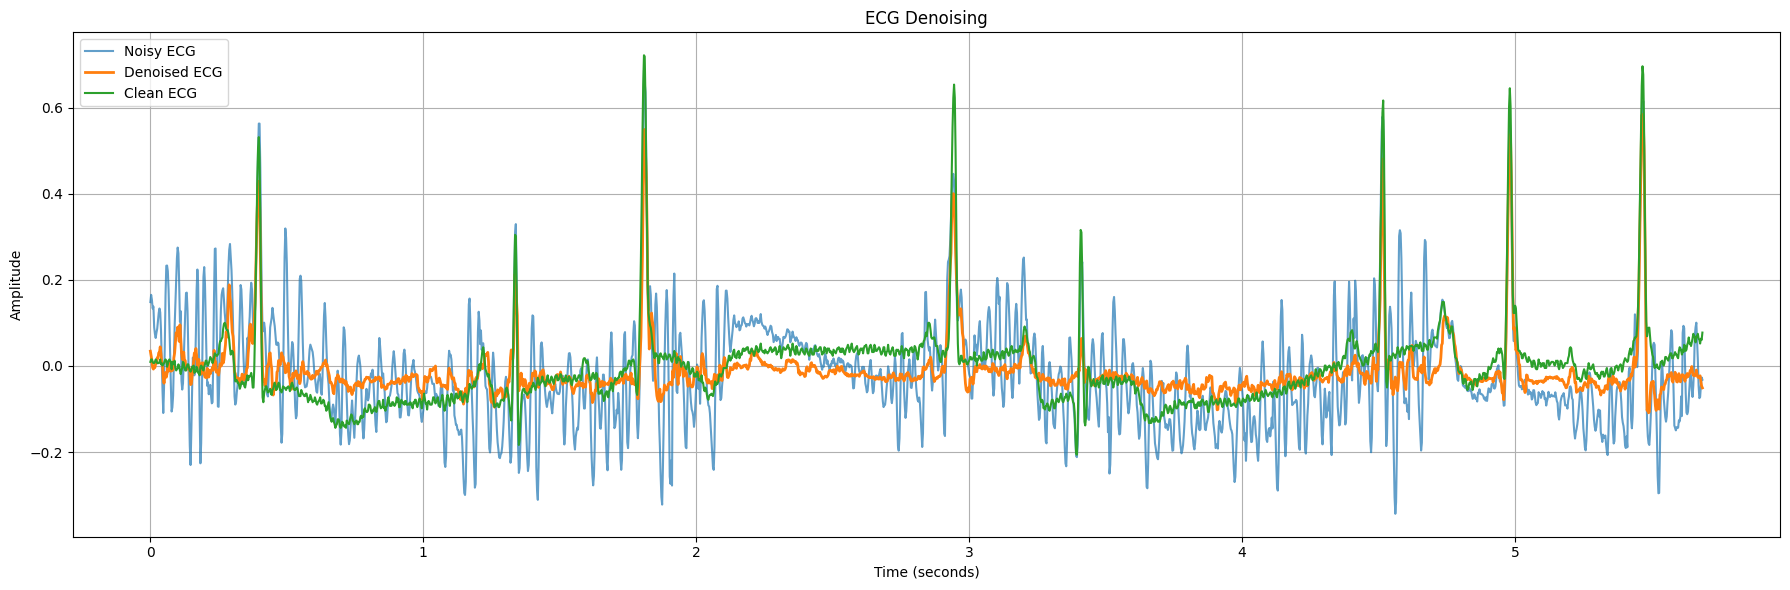

In [45]:
visualize_ecg_signals(
    noisy=x_test[idx:idx+1],
    denoised=denoised_segment,
    clean=clean_segment,
    fs=360
)

In [59]:
idx = 305
noisy_segment = x_train[idx]
clean_segment = y_train[idx]

device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
model.eval()
with torch.no_grad():

    noisy_input = (x_train[idx:idx+1].to(device))
    denoised_segment = model(noisy_input)

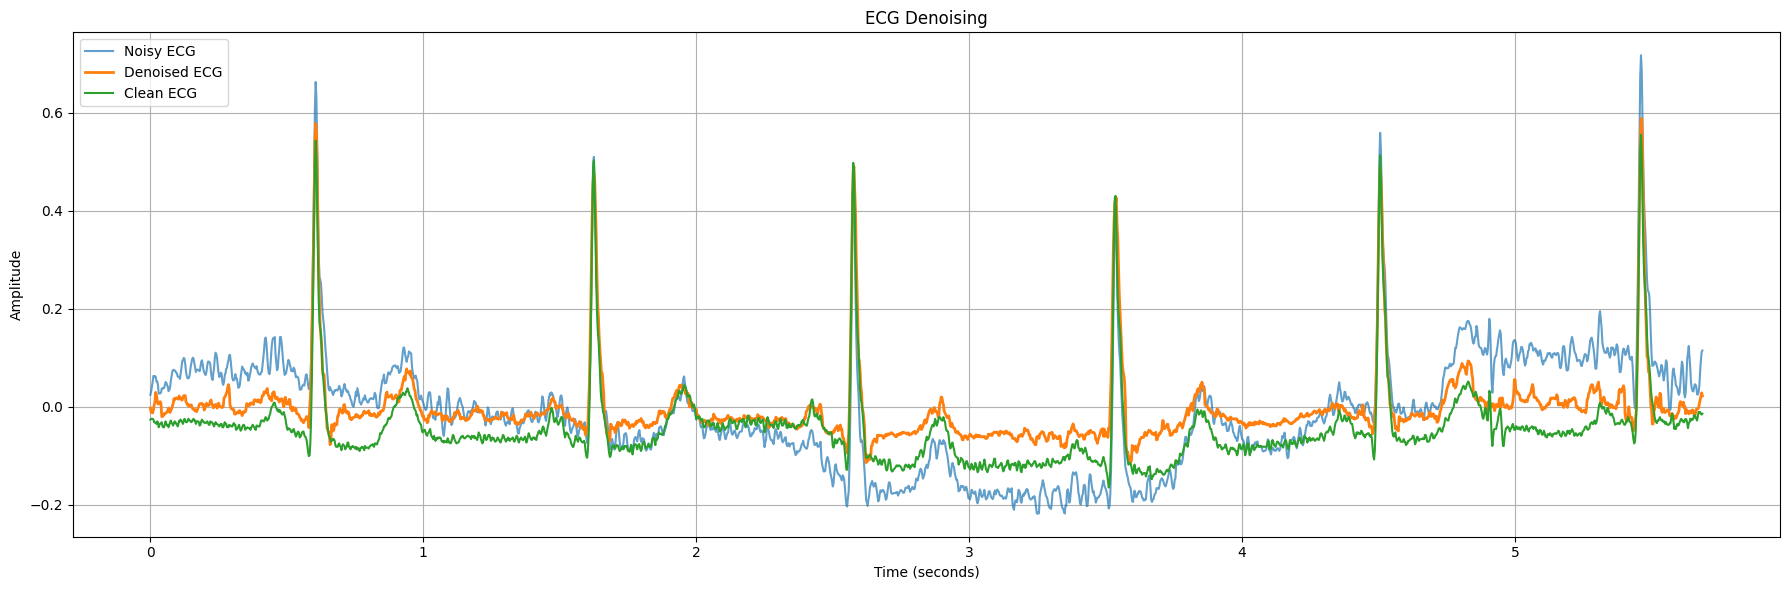

In [60]:
visualize_ecg_signals(
    noisy=x_train[idx:idx+1],
    denoised=denoised_segment,
    clean=clean_segment,
    fs=360
)

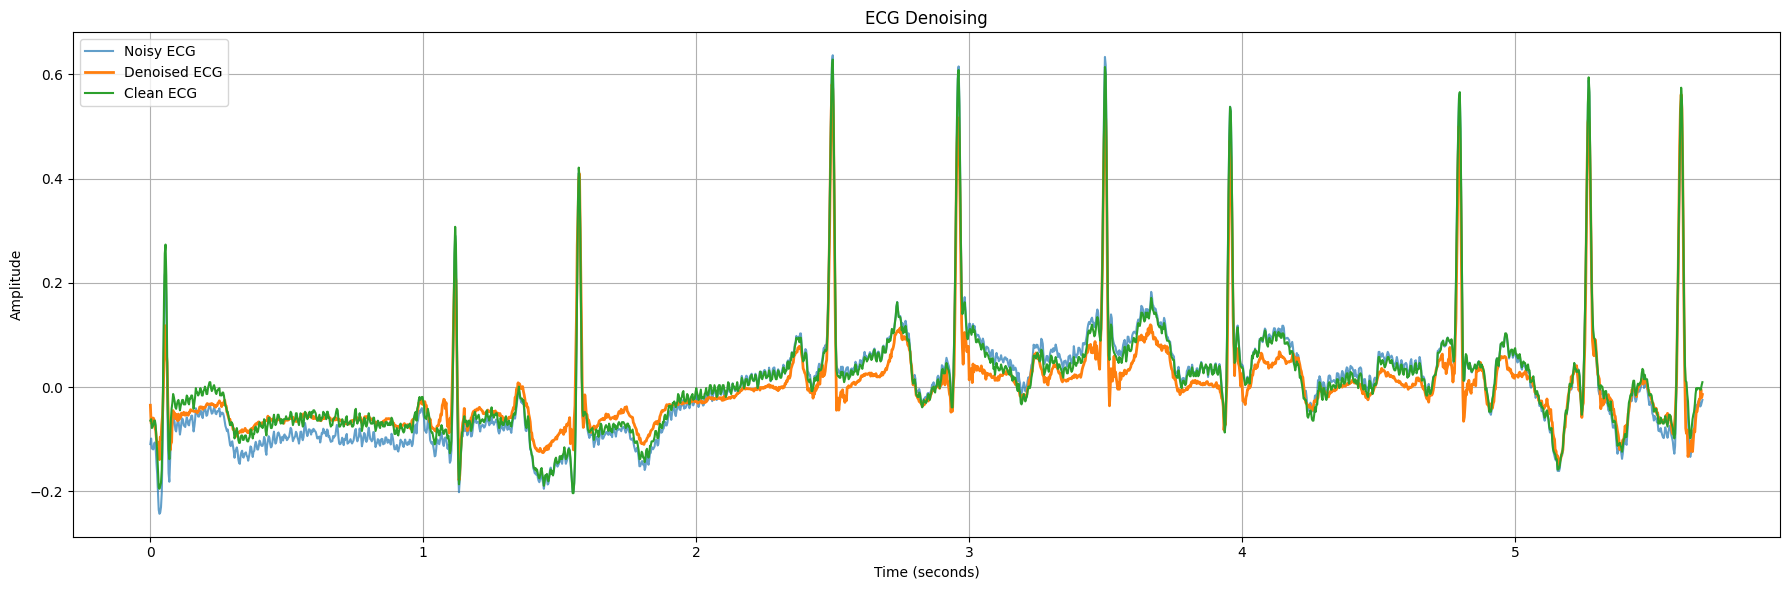

In [54]:
visualize_ecg_signals(
    noisy=x_test[idx:idx+1],
    denoised=denoised_segment,
    clean=clean_segment,
    fs=360
)

In [49]:
def plot_segment(data,
                 metadata,
                 segment_index,
                 title="ECG Segment"):

    """
    Plot a specific ECG segment and print its metadata.

    Parameters
    ----------
    data : np.ndarray
        Shape: (N, 1, 2048)

    metadata : list
        Metadata list corresponding to segments

    segment_index : int
        Index of segment to visualize

    title : str
        Plot title
    """

    # Get segment
    segment = data[segment_index, 0]

    # Get metadata
    meta = metadata[segment_index]

    # =========================
    # Print Metadata
    # =========================

    print("=" * 50)

    print(f"Segment Index : {segment_index}")

    print(f"Patient Record: {meta['record']}")

    print(f"Segment ID    : {meta['segment_idx']}")

    print(f"Start Sample  : {meta['start']}")

    print(f"End Sample    : {meta['end']}")

    if 'noise_type' in meta:
        print(f"Noise Type    : {meta['noise_type']}")

    if 'target_snr_db' in meta:
        print(f"Target SNR    : {meta['target_snr_db']} dB")

    if 'actual_snr_db' in meta:
        print(f"Actual SNR    : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    # =========================
    # Plot
    # =========================

    plt.figure(figsize=(15,4))

    plt.plot(segment)

    plt.title(title)

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.grid(True)

    plt.show()


def compare_segment(clean_data,
                    noisy_data,
                    metadata,
                    segment_index):

    clean = clean_data[segment_index, 0]

    noisy = noisy_data[segment_index, 0]

    meta = metadata[segment_index]

    print("=" * 50)

    print(f"Patient Record: {meta['record']}")

    print(f"Noise Type   : {meta['noise_type']}")

    print(f"Target SNR   : {meta['target_snr_db']} dB")

    print(f"Actual SNR   : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    plt.figure(figsize=(18,5))

    plt.plot(clean,
             label='Clean',
             linewidth=2)

    plt.plot(noisy,
             label='Noisy',
             alpha=0.7)

    plt.title(
        f"Segment {segment_index}"
    )

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.legend()

    plt.grid(True)

    plt.show()

Patient Record: 101
Noise Type   : MA
Target SNR   : 1.25 dB
Actual SNR   : 1.25 dB


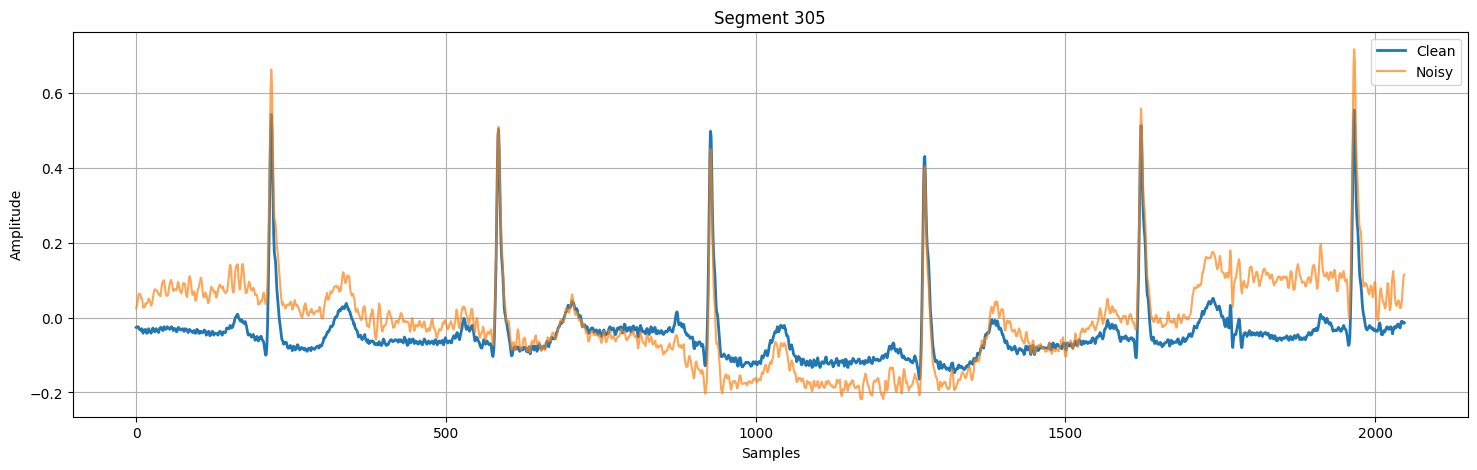

In [56]:
compare_segment(
    y_train,
    x_train,
    train_metadata,
    segment_index=305
)

# Downstream Classification